In [16]:
import hdbscan
from sklearn.datasets import make_blobs, make_moons
import numpy as np
from foscx import FOSCX
from PlotFunctions import plot_tree_with_highlight, plot_Clustering_2d
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.cluster import AgglomerativeClustering

In [17]:

# Two close clusters
X1, _ = make_blobs(
    n_samples=300,
    centers=[(-3, 0), (1, 0)],
    cluster_std=[0.9, 0.9],
    random_state=42
)

# One well-separated cluster
X2, _ = make_blobs(
    n_samples=150,
    centers=[(5, 5)],
    cluster_std=[0.6],
    random_state=42
)

X = np.vstack([X1, X2])

# Build hierarchical clustering (SciPy linkage)
Z = hdbscan.HDBSCAN(gen_min_span_tree=True)
Z.fit(X)
# Initialize FOSC
model1 = FOSCX(top_M=1,kmin=1, quality_measure="stability")
model2 = FOSCX(top_M=1,kmin=1, quality_measure="modularity")
model3 = FOSCX(top_M=1,kmin=1, quality_measure="PFCE")

model1.fit(Z)
print(model1.candidates_)
model2.fit(Z)
print(model2.candidates_)
model3.fit(Z)
print(model3.candidates_)


     quality  n_clusters selected_nodes
0  944.94238           2     [452, 451]
    quality  n_clusters   selected_nodes
0  0.563762           3  [452, 454, 453]
    quality  n_clusters selected_nodes
0  2.944041           2     [452, 451]


C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\2668003820.py:27: UserWarning: HDBSCAN input detected: overriding density=False to density=True.
  model1.fit(Z)
C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\2668003820.py:29: UserWarning: HDBSCAN input detected: overriding density=False to density=True.
  model2.fit(Z)
C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\2668003820.py:31: UserWarning: HDBSCAN input detected: overriding density=False to density=True.
  model3.fit(Z)


In [18]:
seed = 23
rng = np.random.default_rng(seed)
X, _ = make_blobs(500, 2, centers=5,cluster_std=np.abs(rng.normal([0.5,0.5,0.5,0.5,0.5])),random_state=seed)

# Build hierarchical clustering (SciPy linkage)
Z = hdbscan.HDBSCAN(gen_min_span_tree=True)
Z.fit(X)
# Initialize FOSC
model1 = FOSCX(top_M=3,kmin=2, quality_measure="stability")
model2 = FOSCX(top_M=3,kmin=2, quality_measure="modularity")
model3 = FOSCX(top_M=3,kmin=2, quality_measure="PFCE")

model1.fit(Z)
model2.fit(Z)
model3.fit(Z)



C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\1675205136.py:13: UserWarning: HDBSCAN input detected: overriding density=False to density=True.
  model1.fit(Z)
C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\1675205136.py:14: UserWarning: HDBSCAN input detected: overriding density=False to density=True.
  model2.fit(Z)
C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\1675205136.py:15: UserWarning: HDBSCAN input detected: overriding density=False to density=True.
  model3.fit(Z)


,top_M,3
,kmin,2
,kmax,None
,min_cluster_size,5
,quality_measure,'PFCE'
,singletons_as_noise,False
,keep_noise_quality,True
,nearest_neighbors,None
,metric,'euclidean'
,density,True
,tie_quality,'stability'


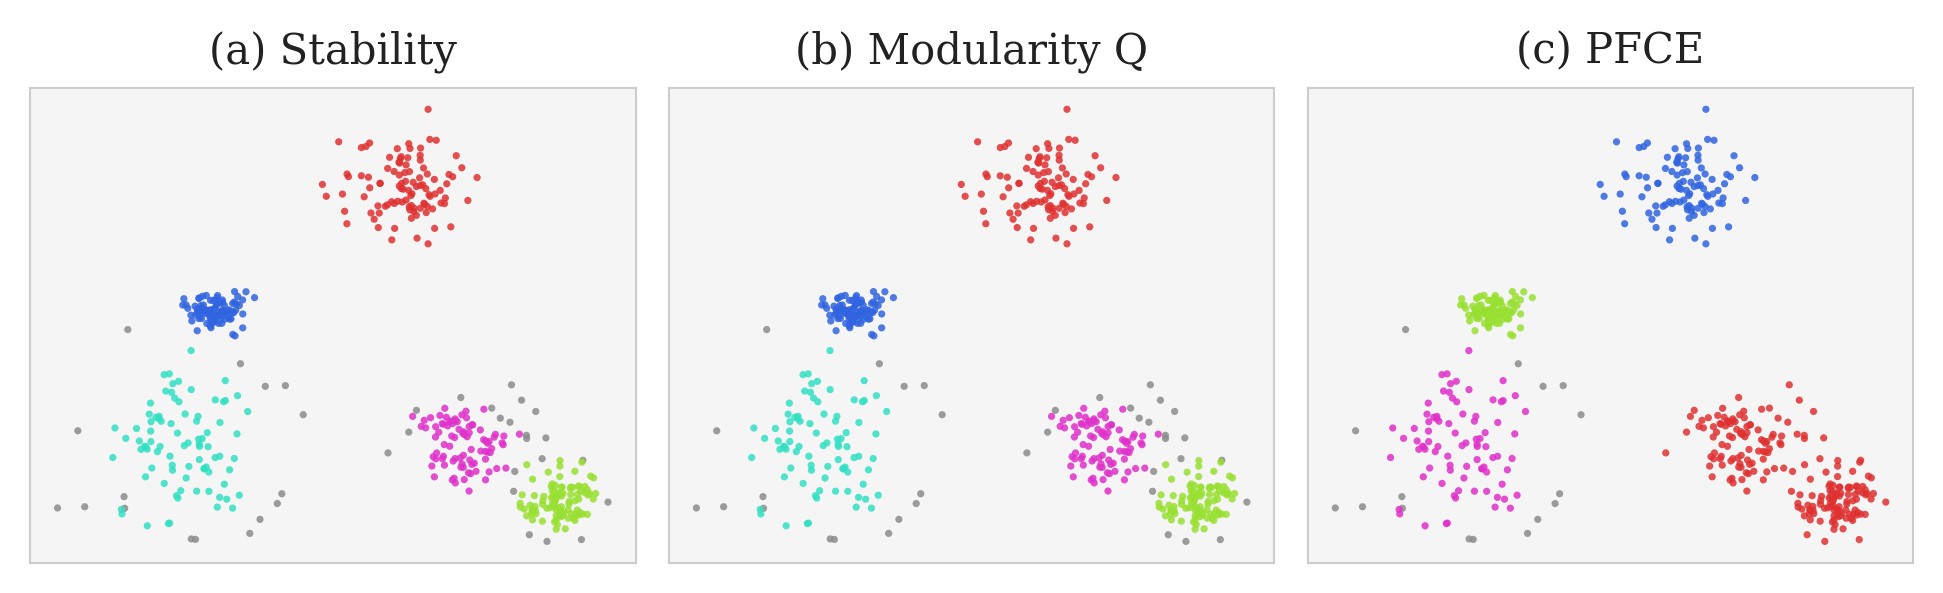

In [19]:
from foscx.plotting.plot_functions import get_scatter_data, plot_fosc_solution

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "figure.dpi": 300
})

# Pre-compute projections once (reuse X, pick your projection)
sd1 = get_scatter_data(model1, X=X, projection="pca")
sd2 = get_scatter_data(model2, X=X, projection="pca")
sd3 = get_scatter_data(model3, X=X, projection="pca")

fig = plt.figure(figsize=(6.5, 2))
gs = GridSpec(1, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

titles = ["(a) Stability", "(b) Modularity Q", "(c) PFCE"]

for ax, sd, title in zip([ax1, ax2, ax3], [sd1, sd2, sd3], titles):
    plot_fosc_solution(sd, solution_idx=0, axis=ax, point_size=3)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

plt.tight_layout(pad=0.8)
plt.savefig("_static/example1.png", bbox_inches="tight")
plt.show()

In [20]:
seed = 5

rng = np.random.default_rng(seed)

X, _ = make_moons(n_samples=400, noise=0.05, random_state=seed)

# Use rng here 
bridge = rng.normal(loc=[0.5, 0.25], scale=0.11, size=(80, 2))

X = np.vstack([X, bridge])
# Build hierarchical clustering (SciPy linkage)
Z = hdbscan.HDBSCAN(gen_min_span_tree=True)
Z.fit(X)
# Initialize FOSC
model1 = FOSCX(top_M=3,kmin=2, quality_measure="stability")
model2 = FOSCX(top_M=3,kmin=2, quality_measure="modularity")
model3 = FOSCX(top_M=3,kmin=2, quality_measure="PFCE")

model1.fit(Z)
print(model1.candidates_)
model2.fit(Z)
print(model2.candidates_)
model3.fit(Z)
print(model3.candidates_)



       quality  n_clusters                                     selected_nodes
0  1608.444741           4                               [483, 485, 486, 482]
1  1598.283721          12  [483, 485, 507, 515, 517, 521, 527, 528, 525, ...
2  1596.757553           5                          [483, 493, 494, 486, 482]
    quality  n_clusters                                 selected_nodes
0  0.621862           6                 [483, 485, 486, 487, 489, 490]
1  0.619899           8       [483, 485, 486, 487, 495, 499, 500, 490]
2  0.617277           9  [483, 485, 486, 487, 495, 505, 506, 500, 490]
    quality  n_clusters        selected_nodes
0  2.832230           3       [483, 484, 482]
1  2.804271           4  [483, 485, 486, 482]
2  2.737101           2            [481, 482]


C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\831492018.py:19: UserWarning: HDBSCAN input detected: overriding density=False to density=True.
  model1.fit(Z)
C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\831492018.py:21: UserWarning: HDBSCAN input detected: overriding density=False to density=True.
  model2.fit(Z)
C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\831492018.py:23: UserWarning: HDBSCAN input detected: overriding density=False to density=True.
  model3.fit(Z)


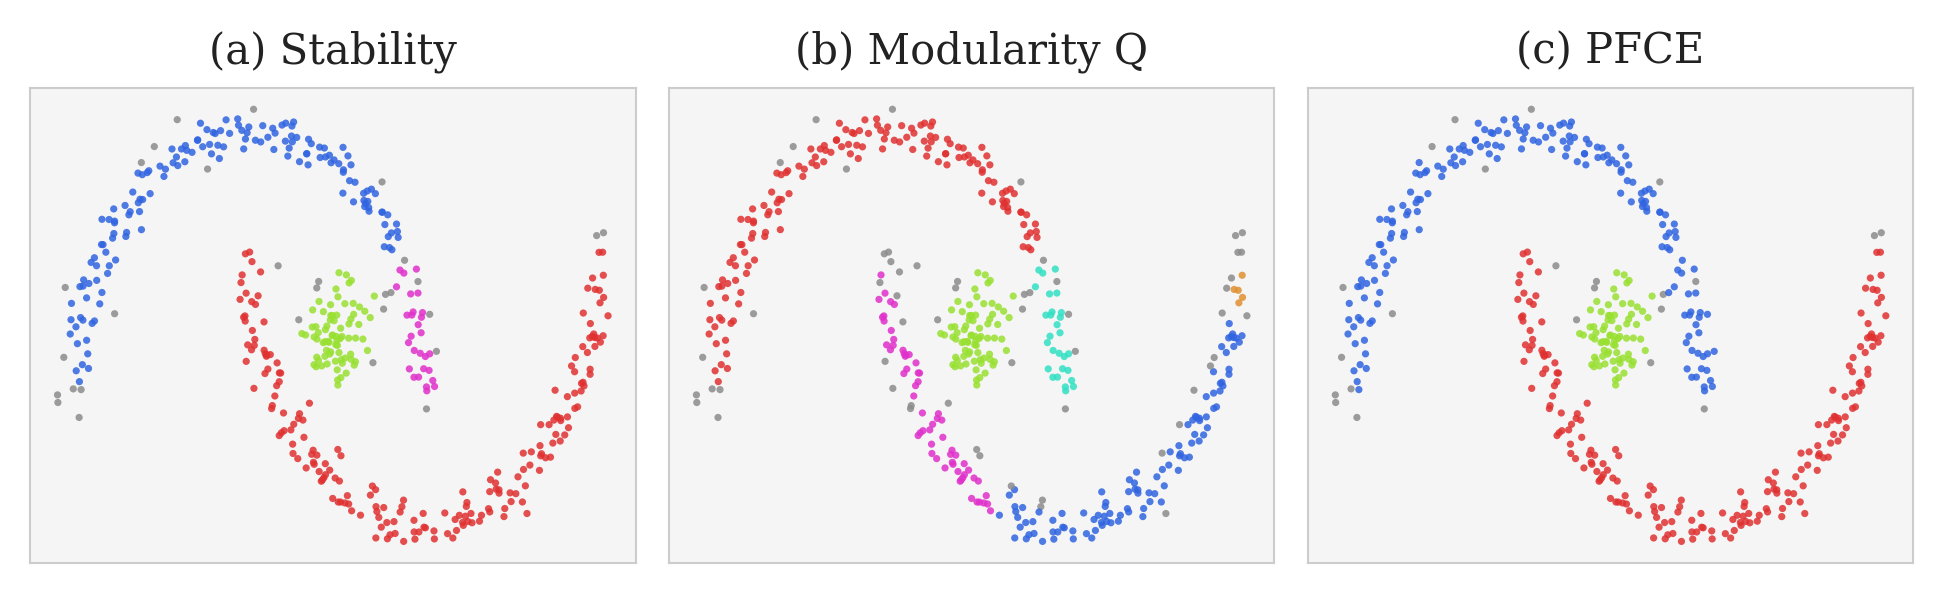

In [21]:
from foscx.plotting.plot_functions import get_scatter_data, plot_fosc_solution

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "figure.dpi": 300
})

# Pre-compute projections once (reuse X, pick your projection)
sd1 = get_scatter_data(model1, X=X, projection="pca")
sd2 = get_scatter_data(model2, X=X, projection="pca")
sd3 = get_scatter_data(model3, X=X, projection="pca")

fig = plt.figure(figsize=(6.5, 2))
gs = GridSpec(1, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

titles = ["(a) Stability", "(b) Modularity Q", "(c) PFCE"]

for ax, sd, title in zip([ax1, ax2, ax3], [sd1, sd2, sd3], titles):
    plot_fosc_solution(sd, solution_idx=0, axis=ax, point_size=3)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

plt.tight_layout(pad=0.8)
plt.savefig("_static/example2.png", bbox_inches="tight")
plt.show()

In [22]:
X = np.load("clusterable_data.npy")
Z = hdbscan.HDBSCAN(min_cluster_size=5,gen_min_span_tree=True)
Z.fit(X)
# Initialize FOSC
model1 = FOSCX(top_M=1,kmin=1, quality_measure="stability")
model2 = FOSCX(top_M=1,kmin=1, quality_measure="modularity")
model3 = FOSCX(top_M=1,kmin=1, quality_measure="PFCE")

model1.fit(Z)
print(model1.candidates_)
model2.fit(Z)
print(model2.candidates_)
model3.fit(Z)
print(model3.candidates_)

C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\3601083603.py:9: UserWarning: HDBSCAN input detected: overriding density=False to density=True.
  model1.fit(Z)
C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\3601083603.py:11: UserWarning: HDBSCAN input detected: overriding density=False to density=True.
  model2.fit(Z)


        quality  n_clusters                                     selected_nodes
0  29843.776741          39  [2315, 2323, 2363, 2362, 2365, 2364, 2360, 235...
    quality  n_clusters                                     selected_nodes
0  0.658286          17  [2315, 2323, 2351, 2350, 2348, 2373, 2372, 236...
   quality  n_clusters selected_nodes
0  2.58154           2   [2311, 2310]


C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\3601083603.py:13: UserWarning: HDBSCAN input detected: overriding density=False to density=True.
  model3.fit(Z)


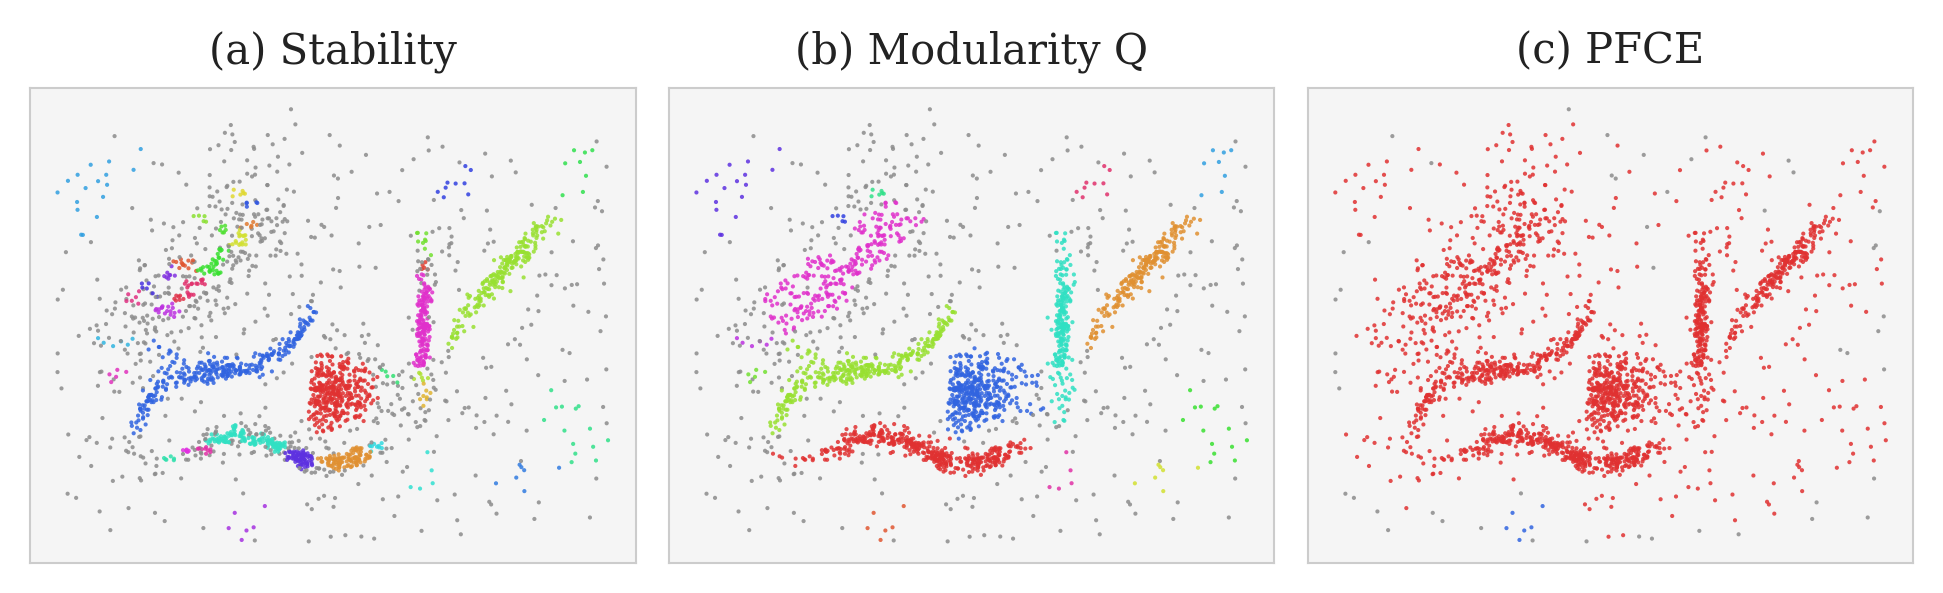

In [23]:
from foscx.plotting.plot_functions import get_scatter_data, plot_fosc_solution

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "figure.dpi": 300
})

# Pre-compute projections once (reuse X, pick your projection)
sd1 = get_scatter_data(model1, X=X, projection="pca")
sd2 = get_scatter_data(model2, X=X, projection="pca")
sd3 = get_scatter_data(model3, X=X, projection="pca")

fig = plt.figure(figsize=(6.5, 2))
gs = GridSpec(1, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

titles = ["(a) Stability", "(b) Modularity Q", "(c) PFCE"]

for ax, sd, title in zip([ax1, ax2, ax3], [sd1, sd2, sd3], titles):
    plot_fosc_solution(sd, solution_idx=0, axis=ax, point_size=1)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

plt.tight_layout(pad=0.8)
plt.savefig("_static/example3.png", bbox_inches="tight")
plt.show()

In [26]:
seed = 23
rng = np.random.default_rng(seed)
X, labels = make_blobs(500, 2, centers=5,cluster_std=np.abs(rng.normal([0.5,0.5,0.5,0.5,0.5])),random_state=seed)

# Build hierarchical clustering (SciPy linkage)
Z = hdbscan.HDBSCAN(10,gen_min_span_tree=True)
#Z = AgglomerativeClustering(n_clusters=None,distance_threshold=0,linkage="ward")
Z.fit(X)
# Initialize FOSC
model1 = FOSCX(top_M=5,kmin=2, quality_measure="modularity",nearest_neighbors=15)
model1.fit(Z,X)

C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\3301085198.py:11: UserWarning: HDBSCAN input detected: overriding density=False to density=True.
  model1.fit(Z,X)
C:\Users\simpson\AppData\Local\Temp\1\ipykernel_31692\3301085198.py:11: UserWarning: Both `y` and clustering-object raw data were provided; using explicit `y` from fit().
  model1.fit(Z,X)


,top_M,5
,kmin,2
,kmax,None
,min_cluster_size,10
,quality_measure,'modularity'
,singletons_as_noise,False
,keep_noise_quality,True
,nearest_neighbors,15
,metric,'euclidean'
,density,True
,tie_quality,'stability'


In [12]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
from foscx.plotting.plot_functions import get_scatter_data, plot_fosc_solution
import matplotlib as mpl
#mpl.rcParams["animation.ffmpeg_path"] = r"C:\Users\simpson\AppData\Roaming\Python\Python313\site-packages\ffmpeg\ffmpeg.exe"

sd = get_scatter_data(model1, X=X, projection="pca")
n_solutions = len(sd["label_sets"])

fig = plt.figure(figsize=(7, 6.5))
gs = GridSpec(2, 1, height_ratios=[10, 1], hspace=0.08)
ax      = fig.add_subplot(gs[0])
ax_bar  = fig.add_subplot(gs[1])

# style the slider axes
ax_bar.set_xlim(0, n_solutions - 1)
ax_bar.set_ylim(0, 1)
ax_bar.set_xticks([])
ax_bar.set_yticks([])
for spine in ax_bar.spines.values():
    spine.set_visible(False)
ax_bar.set_facecolor("#eeeeee")

# track line
ax_bar.axhline(0.5, color="#bbbbbb", linewidth=2, zorder=1)

# slider handle + label — created once, updated each frame
handle, = ax_bar.plot([0], [0.5], "o", color="#333333", ms=8, zorder=3)
label   = ax_bar.text(
    0, -0.6, "Solution 1",
    ha="center", va="top", fontsize=8, color="#444444",
    transform=ax_bar.get_xaxis_transform(),  # x in data, y in axes fraction
)

def animate(i):
    ax.cla()
    plot_fosc_solution(sd, solution_idx=i, axis=ax, point_size=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    handle.set_xdata([i])
    label.set_x(i)
    label.set_text(f"Solution {i + 1} / {n_solutions}")

ani = animation.FuncAnimation(
    fig, animate,
    frames=n_solutions,
    interval=1200,
    repeat=True,
)

ani.save("_static/interactive_plot.gif", writer="pillow", dpi=120)
plt.close(fig)
print(f"Saved {n_solutions}-frame GIF")

Saved 5-frame GIF


In [13]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
from foscx.plotting.cluster_tree_proxy import ClusterTreeProxy
from foscx.plotting.plot_tree_functions import (
    get_plot_data_nb, plot_condensed_nb, plot_selected_nb,
)

# ---- prepare data ----
proxy       = ClusterTreeProxy(model1.cluster_tree_, density=model1.density)
plot_data   = get_plot_data_nb(proxy)
solutions   = list(model1.candidate_nodes_)
qualities   = list(model1.candidate_quality_)
n_solutions = len(solutions)

# ---- build figure once ----
fig = plt.figure(figsize=(7, 6.5))
gs  = GridSpec(2, 1, height_ratios=[14, 1], hspace=0.08)
ax     = fig.add_subplot(gs[0])
ax_bar = fig.add_subplot(gs[1])

plot_condensed_nb(proxy, plot_data, axis=ax)

def _make_title(idx):
    selected = solutions[idx]
    q        = qualities[idx]
    q_str    = f"   ·   quality {q:.3f}" if q is not None else ""
    return (
        f"Solution {idx + 1} / {n_solutions}"
        f"   ·   {len(selected)} cluster{'s' if len(selected) != 1 else ''}"
        f"{q_str}"
    )

title_obj = ax.set_title(_make_title(0), fontsize=10, color="#222222", pad=6)

# ---- style slider axes ----
ax_bar.set_xlim(0, n_solutions - 1)
ax_bar.set_ylim(0, 1)
ax_bar.set_xticks([])
ax_bar.set_yticks([])
for spine in ax_bar.spines.values():
    spine.set_visible(False)
ax_bar.set_facecolor("#eeeeee")

ax_bar.axhline(0.5, color="#bbbbbb", linewidth=2, zorder=1)
ax_bar.vlines(
    range(n_solutions), 0.25, 0.75,
    color="#cccccc", linewidth=0.8, zorder=2,
)

handle, = ax_bar.plot([0], [0.5], "o", color="#333333", ms=8, zorder=3,
                      markeredgecolor="white", markeredgewidth=1.2)
label   = ax_bar.text(
    0, -0.6, _make_title(0),
    ha="center", va="top", fontsize=8, color="#444444",
    transform=ax_bar.get_xaxis_transform(),
)

# ---- animation ----
active_artists = []

def animate(i):
    for artist in active_artists:
        artist.remove()
    active_artists.clear()

    new_artists = plot_selected_nb(solutions[i], plot_data, ax)
    if new_artists:
        active_artists.extend(new_artists)

    title_obj.set_text(_make_title(i))
    handle.set_xdata([i])
    label.set_x(i)
    label.set_text(f"Solution {i + 1} / {n_solutions}")

ani = animation.FuncAnimation(
    fig, animate,
    frames=n_solutions,
    interval=1200,
    repeat=True,
)

ani.save("_static/interactive_tree_plot.gif", writer="pillow", dpi=120)
plt.close(fig)
print(f"Saved {n_solutions}-frame GIF")

Saved 5-frame GIF
